In [1]:
!python -m pip install scikit-learn

Defaulting to user installation because normal site-packages is not writeable



[notice] A new release of pip is available: 26.1.2 -> 26.2
[notice] To update, run: python.exe -m pip install --upgrade pip


# Titanic Survival Prediction using Logistic Regression

## Objective
Build a machine learning classification model to predict whether a passenger survived or not using the Titanic dataset.

In [2]:
import pandas as pd
import numpy 
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import accuracy_score
from sklearn.metrics import confusion_matrix
import matplotlib.pyplot as plt
import seaborn as sns

In [3]:
df = pd.read_csv("Cleaned_Titanic.csv")

In [4]:
df.head()

,PassengerId,Survived,Pclass,Name,Sex,Age,SibSp,Parch,Ticket,Fare,Embarked
0,1,0,3,"Braund, Mr. Owen Harris",male,22.0,1,0,A/5 21171,7.2500,S
1,2,1,1,"Cumings, Mrs. John Bradley (Florence Briggs Th...",female,38.0,1,0,PC 17599,71.2833,C
2,3,1,3,"Heikkinen, Miss. Laina",female,26.0,0,0,STON/O2. 3101282,7.9250,S
3,4,1,1,"Futrelle, Mrs. Jacques Heath (Lily May Peel)",female,35.0,1,0,113803,53.1000,S
4,5,0,3,"Allen, Mr. William Henry",male,35.0,0,0,373450,8.0500,S


In [5]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 891 entries, 0 to 890
Data columns (total 11 columns):
 #   Column       Non-Null Count  Dtype  
---  ------       --------------  -----  
 0   PassengerId  891 non-null    int64  
 1   Survived     891 non-null    int64  
 2   Pclass       891 non-null    int64  
 3   Name         891 non-null    str    
 4   Sex          891 non-null    str    
 5   Age          891 non-null    float64
 6   SibSp        891 non-null    int64  
 7   Parch        891 non-null    int64  
 8   Ticket       891 non-null    str    
 9   Fare         891 non-null    float64
 10  Embarked     891 non-null    str    
dtypes: float64(2), int64(5), str(4)
memory usage: 76.7 KB


## Step 2: Load Dataset

Loaded the Titanic dataset into a pandas DataFrame for machine learning.

In [6]:
x=df.drop("Survived",axis=1)
y=df["Survived"]

In [7]:
x.head()

,PassengerId,Pclass,Name,Sex,Age,SibSp,Parch,Ticket,Fare,Embarked
0,1,3,"Braund, Mr. Owen Harris",male,22.0,1,0,A/5 21171,7.2500,S
1,2,1,"Cumings, Mrs. John Bradley (Florence Briggs Th...",female,38.0,1,0,PC 17599,71.2833,C
2,3,3,"Heikkinen, Miss. Laina",female,26.0,0,0,STON/O2. 3101282,7.9250,S
3,4,1,"Futrelle, Mrs. Jacques Heath (Lily May Peel)",female,35.0,1,0,113803,53.1000,S
4,5,3,"Allen, Mr. William Henry",male,35.0,0,0,373450,8.0500,S


In [8]:
y.head()

0    0
1    1
2    1
3    1
4    0
Name: Survived, dtype: int64

## Step 3: Separate Features and Target

Separated the dataset into input features (X) and the target variable (y). The model will use the features to predict whether a passenger survived or not.

In [9]:
x=pd.get_dummies(x,drop_first=True)

In [10]:
x.head()

,PassengerId,Pclass,Age,SibSp,Parch,Fare,"Name_Abbott, Mr. Rossmore Edward","Name_Abbott, Mrs. Stanton (Rosa Hunt)","Name_Abelson, Mr. Samuel","Name_Abelson, Mrs. Samuel (Hannah Wizosky)",...,Ticket_W./C. 14258,Ticket_W./C. 14263,Ticket_W./C. 6607,Ticket_W./C. 6608,Ticket_W./C. 6609,Ticket_W.E.P. 5734,Ticket_W/C 14208,Ticket_WE/P 5735,Embarked_Q,Embarked_S
0,1,3,22.0,1,0,7.2500,False,False,False,False,...,False,False,False,False,False,False,False,False,False,True
1,2,1,38.0,1,0,71.2833,False,False,False,False,...,False,False,False,False,False,False,False,False,False,False
2,3,3,26.0,0,0,7.9250,False,False,False,False,...,False,False,False,False,False,False,False,False,False,True
3,4,1,35.0,1,0,53.1000,False,False,False,False,...,False,False,False,False,False,False,False,False,False,True
4,5,3,35.0,0,0,8.0500,False,False,False,False,...,False,False,False,False,False,False,False,False,False,True


In [11]:
y.head()

0    0
1    1
2    1
3    1
4    0
Name: Survived, dtype: int64

In [12]:
x.columns

Index(['PassengerId', 'Pclass', 'Age', 'SibSp', 'Parch', 'Fare',
       'Name_Abbott, Mr. Rossmore Edward',
       'Name_Abbott, Mrs. Stanton (Rosa Hunt)', 'Name_Abelson, Mr. Samuel',
       'Name_Abelson, Mrs. Samuel (Hannah Wizosky)',
       ...
       'Ticket_W./C. 14258', 'Ticket_W./C. 14263', 'Ticket_W./C. 6607',
       'Ticket_W./C. 6608', 'Ticket_W./C. 6609', 'Ticket_W.E.P. 5734',
       'Ticket_W/C 14208', 'Ticket_WE/P 5735', 'Embarked_Q', 'Embarked_S'],
      dtype='str', length=1579)

In [13]:
x.shape

(891, 1579)

## Step 4: Encode Categorical Data

Converted categorical columns into numerical values using `pd.get_dummies()` so the machine learning model can process them.

In [14]:
x_train, x_test, y_train, y_test = train_test_split(x,y,test_size=0.2,random_state=42)

In [15]:
print("Training data shape:", x_train.shape)
print("Testing data shape:", x_test.shape)
print("Training labels shape:", y_train.shape)
print("Testing labels shape:", y_test.shape)

Training data shape: (712, 1579)
Testing data shape: (179, 1579)
Training labels shape: (712,)
Testing labels shape: (179,)


## Step 5: Split the Dataset

Split the dataset into training and testing sets. The model learns from the training data and is evaluated on unseen testing data.

In [16]:
model = LogisticRegression()
model.fit(x_train,y_train)

C:\Users\DELL\AppData\Roaming\Python\Python311\site-packages\sklearn\linear_model\_logistic.py:599: ConvergenceWarning: lbfgs failed to converge after 100 iteration(s) (status=1):
STOP: TOTAL NO. OF ITERATIONS REACHED LIMIT

Increase the number of iterations to improve the convergence (max_iter=100).
You might also want to scale the data as shown in:
    https://scikit-learn.org/stable/modules/preprocessing.html
Please also refer to the documentation for alternative solver options:
    https://scikit-learn.org/stable/modules/linear_model.html#logistic-regression
  n_iter_i = _check_optimize_result(


,"penalty penalty: {'l1', 'l2', 'elasticnet', None}, default='l2'Specify the norm of the penalty:- `None`: no penalty is added;- `'l2'`: add an L2 penalty term and it is the default choice;- `'l1'`: add an L1 penalty term;- `'elasticnet'`: both L1 and L2 penalty terms are added... warning:: Some penalties may not work with some solvers. See the parameter `solver` below, to know the compatibility between the penalty and solver... versionadded:: 0.19 l1 penalty with SAGA solver (allowing 'multinomial' + L1).. deprecated:: 1.8 `penalty` was deprecated in version 1.8 and will be removed in 1.10. Use `l1_ratio` and `C` instead. `l1_ratio=0` for `penalty='l2'`, `l1_ratio=1` for `penalty='l1'`, `l1_ratio` set to any float between 0 and 1 for `penalty='elasticnet'`, and `C=np.inf` for `penalty=None`.",'deprecated'
,"C C: float, default=1.0Inverse of regularization strength; must be a positive float.Like in support vector machines, smaller values specify strongerregularization. `C=np.inf` results in unpenalized logistic regression.For a visual example on the effect of tuning the `C` parameterwith an L1 penalty, see::ref:`sphx_glr_auto_examples_linear_model_plot_logistic_path.py`.",1.0
,"l1_ratio l1_ratio: float, default=0.0The Elastic-Net mixing parameter, with `0 <= l1_ratio <= 1`. Setting`l1_ratio=1` gives a pure L1-penalty, setting `l1_ratio=0` a pure L2-penalty.Any value between 0 and 1 gives an Elastic-Net penalty of the form`l1_ratio * L1 + (1 - l1_ratio) * L2`... warning:: Certain values of `l1_ratio`, i.e. some penalties, may not work with some solvers. See the parameter `solver` below, to know the compatibility between the penalty and solver... versionchanged:: 1.8 Default value changed from None to 0.0... deprecated:: 1.8 `None` is deprecated and will be removed in version 1.10. Always use `l1_ratio` to specify the penalty type.",0.0
,"dual dual: bool, default=FalseDual (constrained) or primal (regularized, see also:ref:`this equation <regularized-logistic-loss>`) formulation. Dual formulationis only implemented for l2 penalty with liblinear solver. Prefer `dual=False`when n_samples > n_features.",False
,"tol tol: float, default=1e-4Tolerance for stopping criteria.",0.0001
,"fit_intercept fit_intercept: bool, default=TrueSpecifies if a constant (a.k.a. bias or intercept) should beadded to the decision function.",True
,"intercept_scaling intercept_scaling: float, default=1Useful only when the solver `liblinear` is usedand `self.fit_intercept` is set to `True`. In this case, `x` becomes`[x, self.intercept_scaling]`,i.e. a ""synthetic"" feature with constant value equal to`intercept_scaling` is appended to the instance vector.The intercept becomes``intercept_scaling * synthetic_feature_weight``... note:: The synthetic feature weight is subject to L1 or L2 regularization as all other features. To lessen the effect of regularization on synthetic feature weight (and therefore on the intercept) `intercept_scaling` has to be increased.",1
,"class_weight class_weight: dict or 'balanced', default=NoneWeights associated with classes in the form ``{class_label: weight}``.If not given, all classes are supposed to have weight one.The ""balanced"" mode uses the values of y to automatically adjustweights inversely proportional to class frequencies in the input dataas ``n_samples / (n_classes * np.bincount(y))``.Note that these weights will be multiplied with sample_weight (passedthrough the fit method) if sample_weight is specified... versionadded:: 0.17 *class_weight='balanced'*",None
,"random_state random_state: int, RandomState instance, default=NoneUsed when ``solver`` == 'sag', 'saga' or 'liblinear' to shuffle thedata. See :term:`Glossary <random_state>` for details.",None
,"solver solver: {'lbfgs', 'liblinear', 'newton-cg', 'newton-cholesky', 'sag', 'saga'}, default='lbfgs'Algorithm to use in the optimization problem. Default is 'lbfgs'.To choose a solver, you might want to consider the following aspects:- 'lbfgs' is a good default sol

## Step 6: Train the Model

Created and trained a Logistic Regression model using the training dataset.

In [17]:
y_pred=model.predict(x_test)

In [18]:
y_pred[:10]

array([0, 0, 0, 1, 1, 1, 1, 0, 1, 1])

## Step 7: Make Predictions

Used the trained Logistic Regression model to predict passenger survival on the test dataset.

In [19]:
accuracy=accuracy_score(y_test,y_pred)
print("Accuracy of the model:", accuracy)
accuracy=(accuracy_score(y_test,y_pred))*100
print("Accuracy of the model out of 100:", accuracy)

Accuracy of the model: 0.8100558659217877
Accuracy of the model out of 100: 81.00558659217877


## Step 8: Evaluate the Model

Calculated the model accuracy by comparing the predicted values with the actual values.

### Observation

The Logistic Regression model achieved an accuracy of approximately **81%**, indicating how many predictions were correctly classified.

In [20]:
cm=confusion_matrix(y_test,y_pred)
print("Confusion Matrix:\n",cm)

Confusion Matrix:
 [[92 13]
 [21 53]]


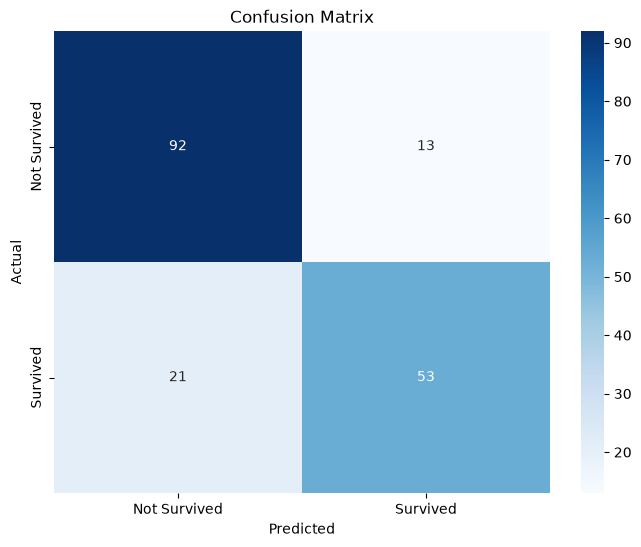

In [21]:
plt.figure(figsize=(8,6))
sns.heatmap(cm,annot=True,fmt="d",cmap="Blues",xticklabels=["Not Survived","Survived"],yticklabels=["Not Survived","Survived"])
plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.title("Confusion Matrix")
plt.show()

## Step 9: Confusion Matrix

Generated a confusion matrix to compare the actual values with the predicted values and evaluate the model's performance.

### Observation

The confusion matrix shows how many passengers were correctly and incorrectly classified. It compares the model's predictions with the actual survival values, helping identify where the model performed well and where it made mistakes.

## Classification Report

The classification report provides Precision, Recall, and F1 Score for each class.

### Precision

Precision measures how many passengers predicted as survivors actually survived.

### Recall

Recall measures how many actual survivors were correctly identified by the model.

### F1 Score

F1 Score is the balance between Precision and Recall and provides a single measure of classification performance.

In [22]:
from sklearn.metrics import classification_report
print(classification_report(y_test,y_pred))

              precision    recall  f1-score   support

           0       0.81      0.88      0.84       105
           1       0.80      0.72      0.76        74

    accuracy                           0.81       179
   macro avg       0.81      0.80      0.80       179
weighted avg       0.81      0.81      0.81       179



## Observation

The Logistic Regression model achieved an accuracy of 81%, indicating good overall performance in predicting passenger survival. The precision for both classes is around 80%, which means most predictions made by the model are correct. The recall for class 0 (Did Not Survive) is higher (88%) than for class 1 (Survived) (72%), showing that the model is better at identifying passengers who did not survive. The F1-scores of 0.84 and 0.76 indicate a balanced performance, although there is still room for improvement in detecting survivors.

## Why Accuracy Can Be Misleading

Accuracy alone can be misleading when the dataset is imbalanced. For example, if most passengers did not survive, a model could predict "did not survive" for everyone and still achieve high accuracy. Precision, Recall, and F1 Score provide a more complete evaluation of model performance.

## Hyperparameter Tuning

Hyperparameter tuning helps find the best settings for a machine learning model. Instead of using default values, GridSearchCV tests multiple parameter combinations and selects the best-performing model automatically.

In this project, the following hyperparameters were tuned:

- C (Regularization Strength)
- Solver (Optimization Algorithm)

In [23]:
from sklearn.model_selection import GridSearchCV
from sklearn.linear_model import LogisticRegression
param_grid = {
    "C": [0.01, 0.1, 1, 10],
    "solver": ["liblinear", "lbfgs"]
}


## Applying GridSearchCV

GridSearchCV tests different combinations of hyperparameters using 5-fold cross-validation and selects the combination that gives the best accuracy.

In [26]:
grid=GridSearchCV(
    LogisticRegression(max_iter=1000),
    param_grid,
    cv=5,
    scoring="accuracy"
)

grid.fit(x_train,y_train)

C:\Users\DELL\AppData\Roaming\Python\Python311\site-packages\sklearn\linear_model\_logistic.py:599: ConvergenceWarning: lbfgs failed to converge after 1000 iteration(s) (status=1):
STOP: TOTAL NO. OF ITERATIONS REACHED LIMIT

Increase the number of iterations to improve the convergence (max_iter=1000).
You might also want to scale the data as shown in:
    https://scikit-learn.org/stable/modules/preprocessing.html
Please also refer to the documentation for alternative solver options:
    https://scikit-learn.org/stable/modules/linear_model.html#logistic-regression
  n_iter_i = _check_optimize_result(
C:\Users\DELL\AppData\Roaming\Python\Python311\site-packages\sklearn\linear_model\_logistic.py:599: ConvergenceWarning: lbfgs failed to converge after 1000 iteration(s) (status=1):
STOP: TOTAL NO. OF ITERATIONS REACHED LIMIT

Increase the number of iterations to improve the convergence (max_iter=1000).
You might also want to scale the data as shown in:
    https://scikit-learn.org/stable/m

,"estimator estimator: estimator objectThis is assumed to implement the scikit-learn estimator interface.Either estimator needs to provide a ``score`` function,or ``scoring`` must be passed.",LogisticRegre...max_iter=1000)
,"param_grid param_grid: dict or list of dictionariesDictionary with parameters names (`str`) as keys and lists ofparameter settings to try as values, or a list of suchdictionaries, in which case the grids spanned by each dictionaryin the list are explored. This enables searching over any sequenceof parameter settings.","{'C': [0.01, 0.1, ...], 'solver': ['liblinear', 'lbfgs']}"
,"scoring scoring: str, callable, list, tuple or dict, default=NoneStrategy to evaluate the performance of the cross-validated model onthe test set.If `scoring` represents a single score, one can use:- a single string (see :ref:`scoring_string_names`);- a callable (see :ref:`scoring_callable`) that returns a single value;- `None`, the `estimator`'s :ref:`default evaluation criterion <scoring_api_overview>` is used.If `scoring` represents multiple scores, one can use:- a list or tuple of unique strings;- a callable returning a dictionary where the keys are the metric names and the values are the metric scores;- a dictionary with metric names as keys and callables as values.See :ref:`multimetric_grid_search` for an example.",'accuracy'
,"cv cv: int, cross-validation generator or an iterable, default=NoneDetermines the cross-validation splitting strategy.Possible inputs for cv are:- None, to use the default 5-fold cross validation,- integer, to specify the number of folds in a `(Stratified)KFold`,- :term:`CV splitter`,- an iterable yielding (train, test) splits as arrays of indices.For integer/None inputs, if the estimator is a classifier and ``y`` iseither binary or multiclass, :class:`StratifiedKFold` is used. In allother cases, :class:`KFold` is used. These splitters are instantiatedwith `shuffle=False` so the splits will be the same across calls.Refer :ref:`User Guide <cross_validation>` for the variouscross-validation strategies that can be used here... versionchanged:: 0.22 ``cv`` default value if None changed from 3-fold to 5-fold.",5
,"n_jobs n_jobs: int, default=NoneNumber of jobs to run in parallel.``None`` means 1 unless in a :obj:`joblib.parallel_backend` context.``-1`` means using all processors. See :term:`Glossary <n_jobs>`for more details... versionchanged:: v0.20 `n_jobs` default changed from 1 to None",None
,"refit refit: bool, str, or callable, default=TrueRefit an estimator using the best found parameters on the wholedataset.For multiple metric evaluation, this needs to be a `str` denoting thescorer that would be used to find the best parameters for refittingthe estimator at the end.Where there are considerations other than maximum score inchoosing a best estimator, ``refit`` can be set to a function whichreturns the selected ``best_index_`` given ``cv_results_``. In thatcase, the ``best_estimator_`` and ``best_params_`` will be setaccording to the returned ``best_index_`` while the ``best_score_``attribute will not be available.The refitted estimator is made available at the ``best_estimator_``attribute and permits using ``predict`` directly on this``GridSearchCV`` instance.Also for multiple metric evaluation, the attributes ``best_index_``,``best_score_`` and ``best_params_`` will only be available if``refit`` is set and all of them will be determined w.r.t this specificscorer.See ``scoring`` parameter to know more about multiple metricevaluation.See :ref:`sphx_glr_auto_examples_model_selection_plot_grid_search_digits.py`to see how to design a custom selection strategy using a callablevia `refit`.See :ref:`this example<sphx_glr_auto_examples_model_selection_plot_grid_search_refit_callable.py>`for an example of how to use ``refit=callable`` to balance modelcomplexity and cross-validated score... versionchanged:: 0.20 Support for callable added.",True
,"verbose verbose: int, default=0Controls the verbosity of informa

## Best Hyperparameters

The best hyperparameter combination selected by GridSearchCV is shown below.

In [27]:
print("Best parameters found: ", grid.best_params_)

Best parameters found:  {'C': 10, 'solver': 'lbfgs'}


## Best Hyperparameters

The best hyperparameter combination selected by GridSearchCV is shown below.

In [32]:
best_model = grid.best_estimator_
y_pred_tumed = best_model.predict(x_test)
print("Tuned model predictions:", y_pred_tumed[:10])
print("best_model:", best_model)

Tuned model predictions: [0 0 0 1 1 1 1 0 1 1]
best_model: LogisticRegression(C=10, max_iter=1000)


### Observation

The best model selected by GridSearchCV uses C=10. This configuration achieved the highest cross-validation performance among all tested parameter combinations and was used to generate predictions on the test dataset.

## Tuned Model Performance

The tuned model is evaluated using the same test dataset to compare its performance with the original model

In [29]:
from sklearn.metrics import accuracy_score

tuned_accuracy=accuracy_score(y_test,y_pred_tumed)
print("Original Accuracy of the model:", accuracy)
print("Tuned Accuracy of the model:", tuned_accuracy)

Original Accuracy of the model: 81.00558659217877
Tuned Accuracy of the model: 0.8268156424581006


### Observation

The original Logistic Regression model achieved an accuracy of 81.01%, while the tuned model achieved an accuracy of 82.68%. This shows that hyperparameter tuning slightly improved the model's predictive performance and helped achieve better classification results.

## Performance Comparison

The table below compares the performance of the original model and the tuned model.

In [30]:
comparion=pd.DataFrame({
    "Model":["Original Model","Tuned Model"],
    "Accuracy":[accuracy,tuned_accuracy]
}
)
comparion

,Model,Accuracy
0,Original Model,81.005587
1,Tuned Model,0.826816


### Observation

The comparison table shows that the tuned model outperformed the original model. Accuracy improved from 81.01% to 82.68%, indicating that selecting optimal hyperparameters can lead to better model performance.

## Final Observation

The Logistic Regression model was evaluated using Accuracy, Precision, Recall, F1 Score, and Confusion Matrix. Hyperparameter tuning was performed using GridSearchCV to identify the best model settings. The tuned model was then compared with the original model. This process demonstrated how proper evaluation and optimization can improve machine learning model performance.